In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from pathlib import Path
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
import os
os.chdir("..")
print("Current working directory:", os.getcwd())

Current working directory: /home/smokehappiest/cnn-age-recognize


In [3]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [4]:
class AgeDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = Path(f"{self.img_dir}/{row['image_name']}")
        image = Image.open(img_path).convert('RGB')
        age = float(row['age'])
        
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)

In [5]:
from torchvision import transforms

basic_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = AgeDataset('datasets/splits/train.csv', 'datasets/splits/train', transform=basic_tfms)
val_ds   = AgeDataset('datasets/splits/val.csv', 'datasets/splits/validate', transform=basic_tfms)
test_ds = AgeDataset('datasets/splits/test.csv', 'datasets/splits/test', transform=basic_tfms)

from torch.utils.data import DataLoader
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False)

In [7]:
import torch.nn as nn
from torchvision import models

class ResNetAgeRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.features = base
        self.head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

In [8]:
from tqdm import tqdm


In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetAgeRegressor().to(device)

criterion = nn.SmoothL1Loss()  # Huber loss

def mae(pred, target):
    return torch.mean(torch.abs(pred - target))

In [13]:
for param in model.features.parameters():
    param.requires_grad = False

optimizer = AdamW(
    model.head.parameters(),
    lr=1e-3,
    weight_decay=1e-2
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

In [16]:
epochs_stage1 = 10
patience = 8
best_val = float('inf')
wait = 0

for epoch in range(epochs_stage1):
    model.train()
    train_loss = 0

    for imgs, ages in tqdm(train_dl, desc=f"Stage1 Epoch {epoch+1}/{epochs_stage1} [Train]"):
        imgs = imgs.to(device)
        ages = ages.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, ages)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    model.eval()
    val_mae = 0

    with torch.no_grad():
        for imgs, ages in tqdm(val_dl, desc=f"Stage1 Epoch {epoch+1}/{epochs_stage1} [Valid]"):
            imgs = imgs.to(device)
            ages = ages.to(device).unsqueeze(1)
            preds = model(imgs)
            val_mae += mae(preds, ages).item() * imgs.size(0)

    train_loss /= len(train_ds)
    val_mae /= len(val_ds)

    print(f"[Stage1] Epoch {epoch+1}: Train Loss={train_loss:.3f}, Val MAE={val_mae:.3f}")
    scheduler.step(val_mae)

Stage1 Epoch 1/10 [Valid]: 100%|██████████| 196/196 [00:11<00:00, 17.75it/s]


[Stage1] Epoch 1: Train Loss=12.039, Val MAE=10.675


Stage1 Epoch 2/10 [Valid]: 100%|██████████| 196/196 [00:10<00:00, 19.23it/s]


[Stage1] Epoch 2: Train Loss=10.190, Val MAE=10.336


Stage1 Epoch 3/10 [Valid]: 100%|██████████| 196/196 [00:10<00:00, 18.66it/s]


...

[Stage1] Epoch 8: Train Loss=8.947, Val MAE=9.865


Stage1 Epoch 9/10 [Valid]: 100%|██████████| 196/196 [00:09<00:00, 20.05it/s]


[Stage1] Epoch 9: Train Loss=8.744, Val MAE=9.659


Stage1 Epoch 10/10 [Valid]: 100%|██████████| 196/196 [00:09<00:00, 19.95it/s]

[Stage1] Epoch 10: Train Loss=8.668, Val MAE=9.573


In [25]:
for name, param in model.features.named_parameters():
    if "layer4" in name:
        param.requires_grad = True


In [26]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6,
    weight_decay=1e-2
)

criterion = nn.SmoothL1Loss()

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)   


In [27]:
model = ResNetAgeRegressor().to(device)
model.load_state_dict(
    torch.load("best_resnet50_age_mae5.pth", map_location=device)
)


epochs_stage2 = 100
wait = 0

for epoch in range(epochs_stage2):
    model.train()
    train_loss = 0

    for imgs, ages in tqdm(train_dl, desc=f"Stage2 Epoch {epoch+1}/{epochs_stage2} [Train]"):
        imgs = imgs.to(device)
        ages = ages.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, ages)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    model.eval()
    val_mae = 0

    with torch.no_grad():
        for imgs, ages in tqdm(val_dl, desc=f"Stage2 Epoch {epoch+1}/{epochs_stage2} [Valid]"):
            imgs = imgs.to(device)
            ages = ages.to(device).unsqueeze(1)
            preds = model(imgs)
            val_mae += mae(preds, ages).item() * imgs.size(0)

    train_loss /= len(train_ds)
    val_mae /= len(val_ds)

    print(f"[Stage2] Epoch {epoch+1}: Train Loss={train_loss:.3f}, Val MAE={val_mae:.3f}")

    scheduler.step(val_mae)

    if val_mae < best_val:
        best_val = val_mae
        torch.save(model.state_dict(), "best_resnet50_age.pth")
        print("✅ Saved new best model")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("⏹ Early stopping triggered")
            break

Stage2 Epoch 1/100 [Valid]: 100%|██████████| 196/196 [00:11<00:00, 17.50it/s]


[Stage2] Epoch 1: Train Loss=1.336, Val MAE=5.203
✅ Saved new best model


Stage2 Epoch 2/100 [Valid]: 100%|██████████| 196/196 [00:10<00:00, 18.67it/s]


[Stage2] Epoch 2: Train Loss=1.343, Val MAE=5.204


Stage2 Epoch 3/100 [Valid]: 100%|██████████| 196/196 [00:10<00:00, 19.16it/s]


...

[Stage2] Epoch 7: Train Loss=1.346, Val MAE=5.228


Stage2 Epoch 8/100 [Valid]: 100%|██████████| 196/196 [00:10<00:00, 18.89it/s]


[Stage2] Epoch 8: Train Loss=1.341, Val MAE=5.238


Stage2 Epoch 9/100 [Valid]: 100%|██████████| 196/196 [00:10<00:00, 19.13it/s]

[Stage2] Epoch 9: Train Loss=1.339, Val MAE=5.224
⏹ Early stopping triggered


In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetAgeRegressor().to(device)
model.load_state_dict(torch.load('best_resnet50_age_mae5.pth', map_location=device))
model.eval()

mse_loss = nn.MSELoss()
mae_loss = nn.L1Loss()

mse_total, mae_total, within5_total = 0, 0, 0
n_samples = 0

with torch.no_grad():
    for imgs, ages in tqdm(test_dl, desc="[Test evaluation]"):
        imgs, ages = imgs.to(device), ages.to(device).unsqueeze(1)
        preds = model(imgs)

        mse_total += mse_loss(preds, ages).item() * imgs.size(0)
        mae_total += mae_loss(preds, ages).item() * imgs.size(0)
        within5_total += ((torch.abs(preds - ages) <= 5).sum().item())

        n_samples += imgs.size(0)

mse = mse_total / n_samples
mae = mae_total / n_samples
within5_acc = within5_total / n_samples * 100

print(f"\n📊 Test results:")
print(f"MSE = {mse:.3f}")
print(f"MAE = {mae:.3f}")
print(f"Accuracy within ±5 years = {within5_acc:.2f}%")

[Test evaluation]: 100%|██████████| 49/49 [00:05<00:00,  8.98it/s]


📊 Test results:
MSE = 53.132
MAE = 5.102
Accuracy within ±5 years = 62.04%


In [32]:
age_bins = [
    (0, 10),
    (10, 20),
    (20, 30),
    (30, 40),
    (40, 50),
    (50, 60),
    (60, 70),
    (70, 120)
]

In [33]:
from collections import defaultdict

bin_mae_sum = defaultdict(float)
bin_count = defaultdict(int)

with torch.no_grad():
    for imgs, ages in tqdm(test_dl, desc="[Test evaluation by age bins]"):
        imgs = imgs.to(device)
        ages = ages.to(device).unsqueeze(1)
        preds = model(imgs)

        abs_errors = torch.abs(preds - ages).squeeze(1)

        for i in range(len(ages)):
            age = ages[i].item()
            err = abs_errors[i].item()

            for low, high in age_bins:
                if low <= age < high:
                    bin_mae_sum[(low, high)] += err
                    bin_count[(low, high)] += 1
                    break
                
                

[Test evaluation by age bins]: 100%|██████████| 49/49 [00:05<00:00,  8.32it/s]


In [30]:
print("\n📊 MAE by age groups:")
for low, high in age_bins:
    cnt = bin_count[(low, high)]
    if cnt > 0:
        mae_bin = bin_mae_sum[(low, high)] / cnt
        print(f"{low:>2}-{high:<3}: MAE = {mae_bin:.2f} (n={cnt})")
    else:
        print(f"{low:>2}-{high:<3}: no samples")


📊 MAE by age groups:
 0-10 : MAE = 2.03 (n=371)
10-20 : MAE = 5.28 (n=260)
20-30 : MAE = 4.08 (n=958)
30-40 : MAE = 4.99 (n=621)
40-50 : MAE = 6.72 (n=316)
50-60 : MAE = 7.11 (n=282)
60-70 : MAE = 6.89 (n=171)
70-120: MAE = 10.41 (n=151)


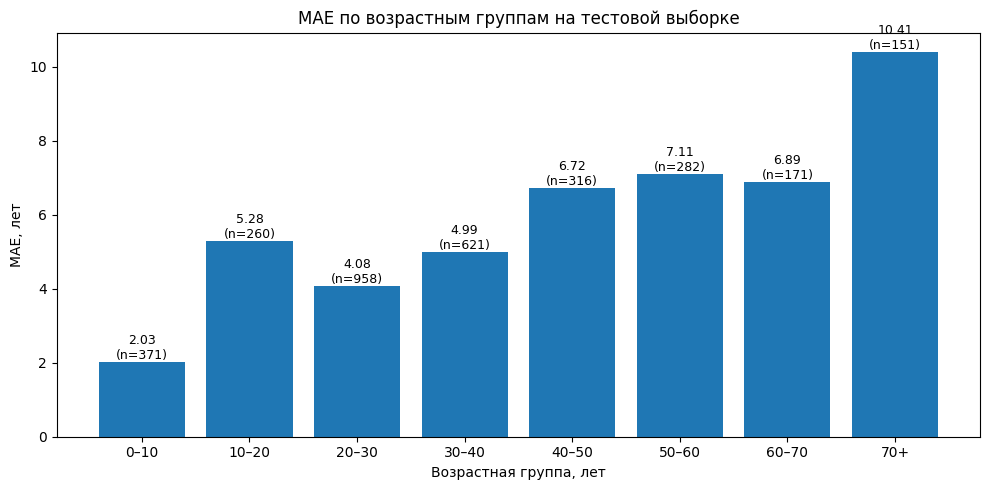

In [34]:
import matplotlib.pyplot as plt

# Данные
age_groups = [
    "0–10", "10–20", "20–30", "30–40",
    "40–50", "50–60", "60–70", "70+"
]

mae_values = [
    2.03, 5.28, 4.08, 4.99,
    6.72, 7.11, 6.89, 10.41
]

sample_counts = [
    371, 260, 958, 621,
    316, 282, 171, 151
]

# Построение
plt.figure(figsize=(10, 5))
bars = plt.bar(age_groups, mae_values)

plt.xlabel("Возрастная группа, лет")
plt.ylabel("MAE, лет")
plt.title("MAE по возрастным группам на тестовой выборке")

# Подписи значений + количество примеров
for bar, mae, n in zip(bars, mae_values, sample_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{mae:.2f}\n(n={n})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()
